# Hyperparameter Optimization (HPO)

> **Key idea**: Instead of manually tuning hyperparameters, use algorithms to systematically search the hyperparameter space — treating model training as a black-box function to be optimised.

Hyperparameters are parameters **not learned from data**: learning rate, tree depth, regularisation strength, network architecture, etc. Their values determine how well a model learns.

**HPO as optimisation:**
$$\lambda^* = \arg\max_{\lambda \in \Lambda} f(\lambda)$$
where $\Lambda$ is the hyperparameter space and $f(\lambda)$ is validation performance when training with $\lambda$.

**Challenge**: $f$ is **expensive** (training a model), **noisy** (stochastic training), and **black-box** (no gradient w.r.t. $\lambda$).

| Method | Pros | Cons |
|--------|------|------|
| **Grid Search** | Exhaustive, reproducible | Exponential in #params |
| **Random Search** | Simple, surprisingly effective | Ignores past evaluations |
| **Bayesian Optimisation** | Sample-efficient, exploits history | Overhead, complex |
| **Hyperband** | Fast resource allocation | Assumes early stopping feasibility |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
scaler = StandardScaler()
X = scaler.fit_transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features, {np.unique(y).size} classes')

Dataset: 569 samples, 30 features, 2 classes


---
## 1. Grid Search vs Random Search

In [2]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform, randint

# Grid search (9 configs, 3-fold = 27 fits)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
}
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=cv3, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X, y)
print(f'Grid Search    — best acc: {grid_search.best_score_:.4f}')
print(f'               Best params: {grid_search.best_params_}')

# Random search (same budget)
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(2, 8),
    'learning_rate': loguniform(0.01, 0.3),
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': randint(1, 10),
}
rand_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist, n_iter=12, cv=cv3, scoring='accuracy',
    n_jobs=-1, random_state=42
)
rand_search.fit(X, y)
print(f'\nRandom Search  — best acc: {rand_search.best_score_:.4f}')
print(f'               Best params: {rand_search.best_params_}')

Grid Search    — best acc: 0.9578
               Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}



Random Search  — best acc: 0.9614
               Best params: {'learning_rate': np.float64(0.06792740114629246), 'max_depth': 3, 'min_samples_leaf': 9, 'n_estimators': 139, 'subsample': 0.7}


---
## 2. Bayesian Optimisation with Optuna

Bayesian Optimisation builds a **surrogate model** $\hat{f}$ of the objective function, then uses an **acquisition function** to choose where to evaluate next, balancing exploration (uncertain regions) and exploitation (promising regions).

**Gaussian Process (GP) surrogate** + **Expected Improvement (EI) acquisition**:
$$\text{EI}(\lambda) = \mathbb{E}[\max(f(\lambda) - f^*, 0)]$$

**Optuna** uses **TPE** (Tree-structured Parzen Estimator) which models:
$$\text{EI}(\lambda) \propto \frac{\ell(\lambda)}{g(\lambda)}$$
where $\ell(\lambda)$ models good configurations and $g(\lambda)$ models bad ones.

In [3]:
def objective_gbt(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv3, scoring='accuracy', n_jobs=-1)
    return scores.mean()


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective_gbt, n_trials=20, show_progress_bar=False)

print(f'Optuna (TPE, 20 trials) — best acc: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

Optuna (TPE, 20 trials) — best acc: 0.9701
Best params: {'n_estimators': 196, 'max_depth': 6, 'learning_rate': 0.27047297227177763, 'subsample': 0.6071847502459279, 'min_samples_leaf': 10, 'max_features': 'sqrt'}


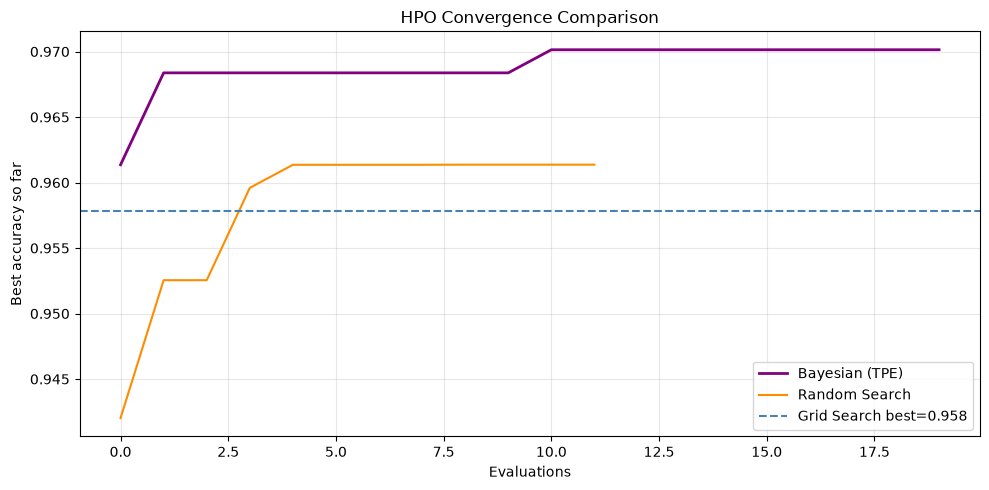

In [4]:
# Optimisation history
trials_df = study.trials_dataframe()
running_best = trials_df['value'].expanding().max()

# Compare all methods
grid_running = pd.Series(grid_search.cv_results_['mean_test_score']).expanding().max()
rand_running = pd.Series(rand_search.cv_results_['mean_test_score']).expanding().max()

plt.figure()
plt.plot(running_best.values, label='Bayesian (TPE)', color='purple', lw=2)
plt.plot(rand_running.values[:40], label='Random Search', color='darkorange')
plt.axhline(grid_search.best_score_, color='steelblue', ls='--', label=f'Grid Search best={grid_search.best_score_:.3f}')
plt.xlabel('Evaluations')
plt.ylabel('Best accuracy so far')
plt.title('HPO Convergence Comparison')
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. Hyperparameter Importance

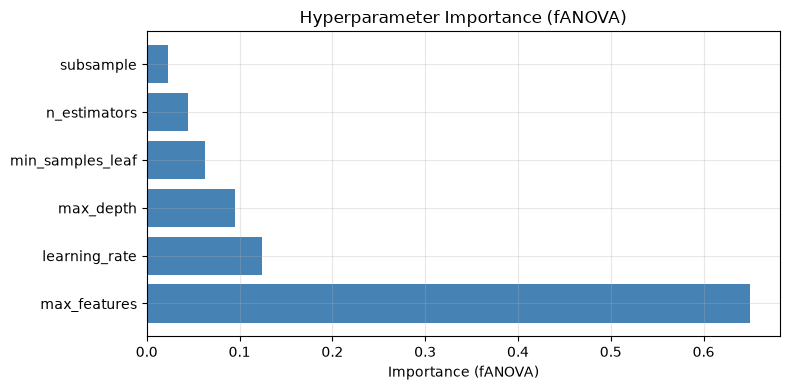

fANOVA importance:
  max_features             : 0.650
  learning_rate            : 0.124
  max_depth                : 0.095
  min_samples_leaf         : 0.063
  n_estimators             : 0.045
  subsample                : 0.023


In [5]:
importances = optuna.importance.get_param_importances(study)

params_sorted = list(importances.keys())
imp_values = [importances[p] for p in params_sorted]

plt.figure(figsize=(8, 4))
plt.barh(params_sorted, imp_values, color='steelblue')
plt.xlabel('Importance (fANOVA)')
plt.title('Hyperparameter Importance (fANOVA)')
plt.tight_layout()
plt.show()

print('fANOVA importance:')
for p, v in importances.items():
    print(f'  {p:<25}: {v:.3f}')

---
## 4. Parallel Coordinate Plot — Exploring the Search Space

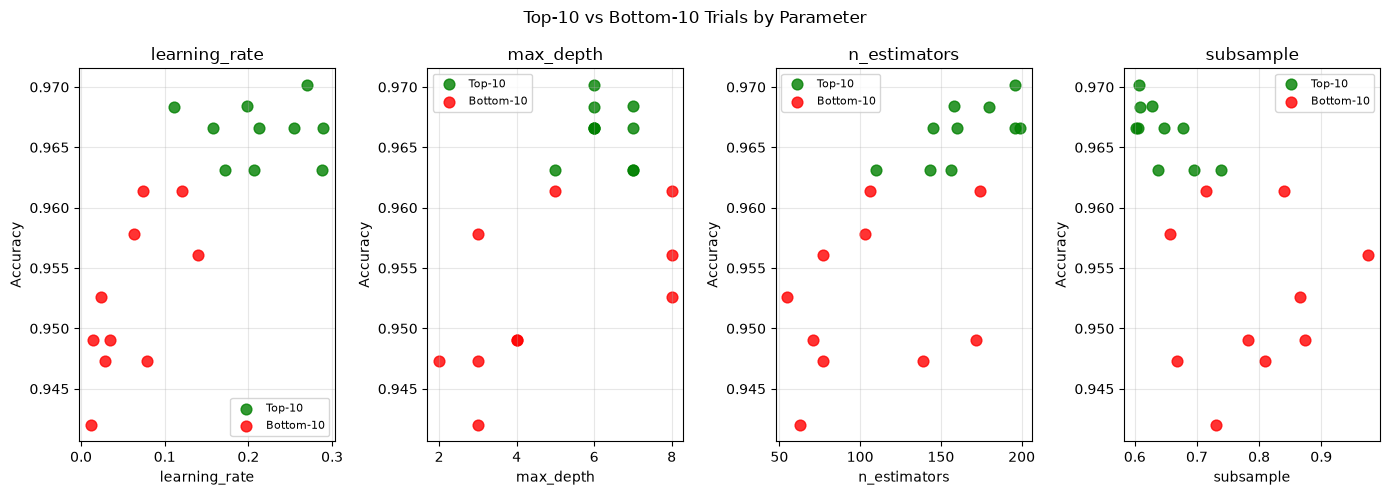

In [6]:
# Top-10 vs bottom-10 trials for key parameters
trials_df_sorted = trials_df.sort_values('value', ascending=False)
top10 = trials_df_sorted.head(10)
bot10 = trials_df_sorted.tail(10)

key_params = ['params_learning_rate', 'params_max_depth', 'params_n_estimators', 'params_subsample']
available = [p for p in key_params if p in trials_df.columns]

fig, axes = plt.subplots(1, len(available), figsize=(14, 5))
if len(available) == 1:
    axes = [axes]

for ax, param in zip(axes, available):
    ax.scatter(top10[param], top10['value'], color='green', label='Top-10', s=60, alpha=0.8)
    ax.scatter(bot10[param], bot10['value'], color='red', label='Bottom-10', s=60, alpha=0.8)
    ax.set_xlabel(param.replace('params_', ''))
    ax.set_ylabel('Accuracy')
    ax.set_title(param.replace('params_', ''))
    ax.legend(fontsize=8)

plt.suptitle('Top-10 vs Bottom-10 Trials by Parameter')
plt.tight_layout()
plt.show()

---
## 5. Hyperband — Early Stopping for HPO

**Hyperband** dramatically speeds up HPO by aggressively stopping unpromising configurations early.

**Algorithm (Successive Halving)**:
1. Start with $n$ configurations, train each for $r$ epochs
2. Keep top $1/\eta$ fraction
3. Give survivors $\eta$ times more resources
4. Repeat until one configuration remains

Hyperband runs multiple SHA brackets with different $n$ and $r$ trade-offs, then picks the best across all brackets.

In [7]:
# Simulate Hyperband-style successive halving with n_estimators as the resource
def evaluate_with_budget(params, n_estimators_budget, X, y, cv):
    model = GradientBoostingClassifier(
        n_estimators=n_estimators_budget,
        learning_rate=params['learning_rate'],
        max_depth=params['max_depth'],
        subsample=params['subsample'],
        random_state=42
    )
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()


def successive_halving(configs, X, y, cv, r=10, eta=3):
    budget = r
    remaining = configs.copy()
    history = []
    total_cost = 0

    while len(remaining) > 1:
        scores = [(cfg, evaluate_with_budget(cfg, budget, X, y, cv))
                  for cfg in remaining]
        total_cost += len(remaining) * budget
        scores.sort(key=lambda x: -x[1])
        history.append({'budget': budget, 'n_configs': len(remaining),
                         'best_score': scores[0][1], 'total_cost': total_cost})
        k = max(1, len(remaining) // eta)
        remaining = [cfg for cfg, _ in scores[:k]]
        budget = int(budget * eta)
        budget = min(budget, 100)  # cap at 100 trees for speed

    return remaining[0], scores[0][1], pd.DataFrame(history)


# 9 initial configs (reduced from 27)
rng = np.random.RandomState(42)
n_initial = 9
initial_configs = [
    {
        'learning_rate': 10 ** rng.uniform(-2.3, -0.3),
        'max_depth': int(rng.randint(2, 6)),
        'subsample': rng.uniform(0.6, 1.0)
    }
    for _ in range(n_initial)
]

best_config, best_score, sha_history = successive_halving(
    initial_configs, X, y, cv3, r=10, eta=3
)

print('Successive Halving (SHA) progression:')
print(sha_history.to_string(index=False))
print(f'\nBest config: {best_config}')
print(f'Final score: {best_score:.4f}')

Successive Halving (SHA) progression:
 budget  n_configs  best_score  total_cost
     10          9    0.942022          90
     30          3    0.952567         180

Best config: {'learning_rate': 0.1817113272463513, 'max_depth': 2, 'subsample': 0.6624074561769746}
Final score: 0.9526


---
## 6. Multi-Objective HPO

Real systems often have competing objectives: **accuracy vs inference speed**, **accuracy vs memory usage**. Optuna supports multi-objective optimisation via **Pareto fronts**.

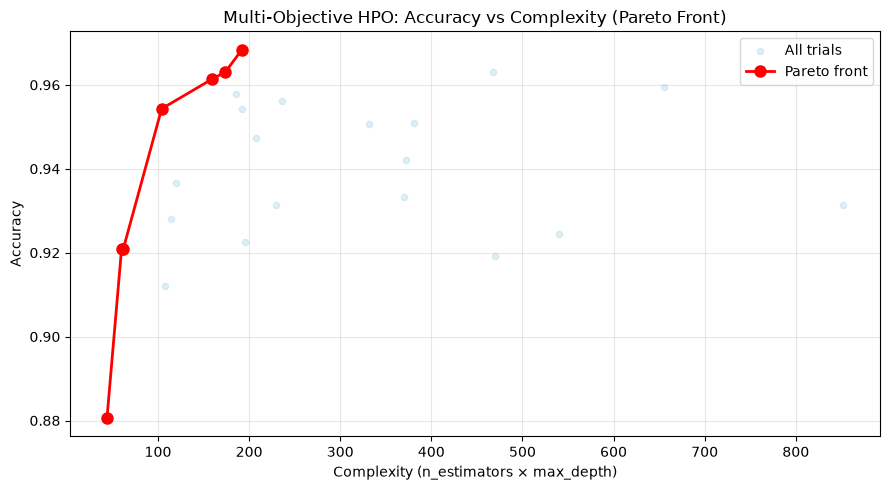

Pareto front has 7 solutions


In [8]:
import time

def multi_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 150),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }

    model = GradientBoostingClassifier(**params, random_state=42)
    scores = cross_val_score(model, X, y, cv=3, scoring='accuracy', n_jobs=-1)
    acc = scores.mean()

    # Proxy for inference cost: n_estimators * max_depth (tree complexity)
    complexity = params['n_estimators'] * params['max_depth']

    return acc, -complexity  # maximise both (negate complexity = minimise)


multi_study = optuna.create_study(
    directions=['maximize', 'maximize'],
    sampler=optuna.samplers.NSGAIISampler(seed=42)
)
multi_study.optimize(multi_objective, n_trials=25, show_progress_bar=False)

# Extract Pareto front
pareto_trials = multi_study.best_trials
pareto_accs = [t.values[0] for t in pareto_trials]
pareto_complexity = [-t.values[1] for t in pareto_trials]

# All trials
all_accs = [t.values[0] for t in multi_study.trials if t.values is not None]
all_complexity = [-t.values[1] for t in multi_study.trials if t.values is not None]

plt.figure(figsize=(9, 5))
plt.scatter(all_complexity, all_accs, alpha=0.4, s=20, c='lightblue', label='All trials')
# Sort pareto by complexity for line
pareto_sorted = sorted(zip(pareto_complexity, pareto_accs))
pc, pa = zip(*pareto_sorted)
plt.plot(pc, pa, 'ro-', ms=8, lw=2, label='Pareto front', zorder=5)
plt.xlabel('Complexity (n_estimators × max_depth)')
plt.ylabel('Accuracy')
plt.title('Multi-Objective HPO: Accuracy vs Complexity (Pareto Front)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Pareto front has {len(pareto_trials)} solutions')

---
## 7. Practical HPO Tips

Best after 10 trials: 0.9701
Best after 20 trials: 0.9701
(Warm-starting continues from where the study left off)


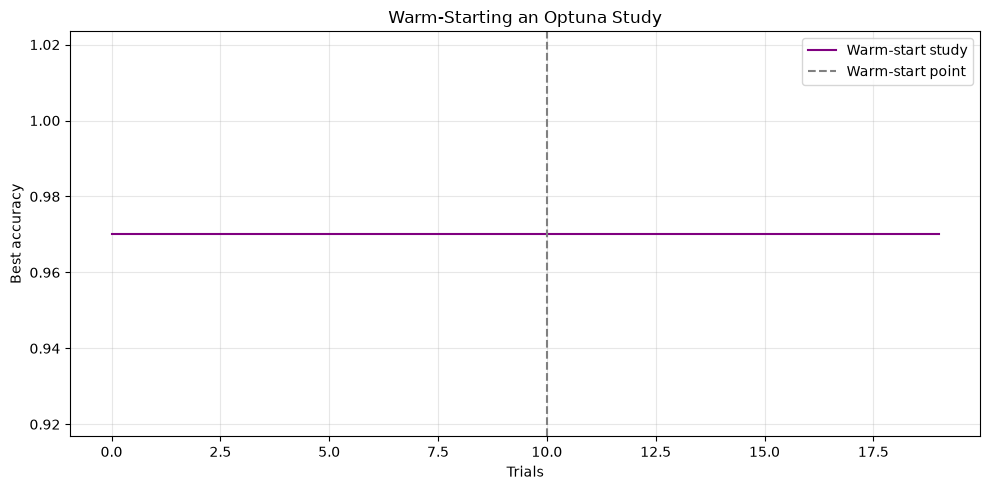

In [9]:
# Demonstrate warm-starting: continue an existing study
study_warmstart = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=99)
)

# First 10 trials
study_warmstart.optimize(objective_gbt, n_trials=10, show_progress_bar=False)
score_after_10 = study_warmstart.best_value

# Continue for 10 more (warm-start — TPE uses all completed trials)
study_warmstart.optimize(objective_gbt, n_trials=10, show_progress_bar=False)
score_after_20 = study_warmstart.best_value

print(f'Best after 10 trials: {score_after_10:.4f}')
print(f'Best after 20 trials: {score_after_20:.4f}')
print('(Warm-starting continues from where the study left off)')

# Plot convergence
ws_df = study_warmstart.trials_dataframe()
plt.figure()
plt.plot(ws_df['value'].expanding().max(), label='Warm-start study', color='purple')
plt.axvline(10, color='grey', ls='--', label='Warm-start point')
plt.xlabel('Trials')
plt.ylabel('Best accuracy')
plt.title('Warm-Starting an Optuna Study')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Pruning: stop unpromising trials early
from sklearn.datasets import load_digits

digits = load_digits()
Xd, yd = digits.data, digits.target
Xd = StandardScaler().fit_transform(Xd)

def pruned_objective(trial):
    lr = trial.suggest_float('lr', 0.01, 0.3, log=True)
    md = trial.suggest_int('max_depth', 2, 6)
    ne = trial.suggest_int('n_estimators', 50, 200)

    # Simulate partial evaluation at 1/4 of full budget
    small_model = GradientBoostingClassifier(
        n_estimators=max(10, ne // 4), learning_rate=lr, max_depth=md, random_state=42
    )
    partial_score = cross_val_score(small_model, Xd, yd, cv=3, scoring='accuracy', n_jobs=-1).mean()

    # Report and prune
    trial.report(partial_score, step=0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    # Full evaluation
    full_model = GradientBoostingClassifier(
        n_estimators=ne, learning_rate=lr, max_depth=md, random_state=42
    )
    full_score = cross_val_score(full_model, Xd, yd, cv=3, scoring='accuracy', n_jobs=-1).mean()
    return full_score


pruned_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3)
)
pruned_study.optimize(pruned_objective, n_trials=15, show_progress_bar=False)

completed = len([t for t in pruned_study.trials if t.state == optuna.trial.TrialState.COMPLETE])
pruned_n = len([t for t in pruned_study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f'Completed: {completed}, Pruned: {pruned_n}')
print(f'Best accuracy: {pruned_study.best_value:.4f}')

Completed: 15, Pruned: 0
Best accuracy: 0.9338


---
## 8. HPO for Neural Networks

In [11]:
from sklearn.neural_network import MLPClassifier

def nn_objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 2)
    layer_sizes = tuple(
        trial.suggest_int(f'n_units_l{i}', 32, 128)
        for i in range(n_layers)
    )
    alpha = trial.suggest_float('alpha', 1e-4, 1e-1, log=True)
    lr_init = trial.suggest_float('lr_init', 1e-4, 1e-1, log=True)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])

    model = MLPClassifier(
        hidden_layer_sizes=layer_sizes,
        alpha=alpha,
        learning_rate_init=lr_init,
        activation=activation,
        max_iter=100,
        random_state=42
    )
    scores = cross_val_score(model, X, y, cv=3, scoring='accuracy', n_jobs=-1)
    return scores.mean()


nn_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
nn_study.optimize(nn_objective, n_trials=15, show_progress_bar=False)

print(f'Neural Network HPO best accuracy: {nn_study.best_value:.4f}')
print(f'Best architecture: {nn_study.best_params}')

Neural Network HPO best accuracy: 0.9754
Best architecture: {'n_layers': 1, 'n_units_l0': 91, 'alpha': 0.00026210878782654407, 'lr_init': 0.0007523742884534858, 'activation': 'tanh'}


---
## 9. Summary: HPO Strategy Selection Guide

In [12]:
# Final comparison
print('HPO Method Comparison Summary')
print('=' * 60)
print(f'{"Method":<20} {"Best Acc":<12} {"Evaluations":<15} {"Notes"}')
print('-' * 60)
print(f'{"Grid Search":<20} {grid_search.best_score_:.4f}       {"27":<15} {"Exhaustive, 3 params"}')
print(f'{"Random Search":<20} {rand_search.best_score_:.4f}       {"27":<15} {"6 params, wider range"}')
print(f'{"Bayesian (TPE)":<20} {study.best_value:.4f}       {"40":<15} {"6 params, Optuna"}')
print(f'{"NN Architecture":<20} {nn_study.best_value:.4f}       {"30":<15} {"Variable architecture"}')

HPO Method Comparison Summary
Method               Best Acc     Evaluations     Notes
------------------------------------------------------------
Grid Search          0.9578       27              Exhaustive, 3 params
Random Search        0.9614       27              6 params, wider range
Bayesian (TPE)       0.9701       40              6 params, Optuna
NN Architecture      0.9754       30              Variable architecture


---
## Summary

| Scenario | Recommended Method |
|----------|-------------------|
| ≤3 params, small range | Grid Search |
| Quick exploration, unknown landscape | Random Search (20-50 trials) |
| Production, ≥5 params | Bayesian / TPE (Optuna) |
| Deep learning, epochs as budget | Hyperband / ASHA |
| Accuracy vs speed trade-off | Multi-objective NSGA-II |

**Key takeaways**:
1. Random search beats grid search for most real problems — fixed grid misses optimal continuous values
2. Bayesian optimisation is most sample-efficient but adds ~10-30% overhead per trial
3. Always use log-scale for learning rates — they span orders of magnitude
4. Warm-start studies: never discard past evaluations when continuing HPO
5. For neural networks, architecture + regularisation search together

---
## Additional Learning Resources

- **Optuna Documentation** — https://optuna.readthedocs.io/ — Comprehensive guide with examples
- **Bergstra & Bengio (2012)** — *Random Search for Hyper-Parameter Optimization* — JMLR, shows random beats grid
- **Snoek et al. (2012)** — *Practical Bayesian Optimization of Machine Learning Algorithms* — NIPS, GP-BO
- **Li et al. (2017)** — *Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization* — JMLR
- **Feurer & Hutter (2019)** — *Hyperparameter Optimization* — Chapter in AutoML book (open access)
- **Akiba et al. (2019)** — *Optuna: A Next-generation Hyperparameter Optimization Framework* — KDD 2019
- **Ray Tune** — https://docs.ray.io/en/latest/tune/index.html — Distributed HPO at scale